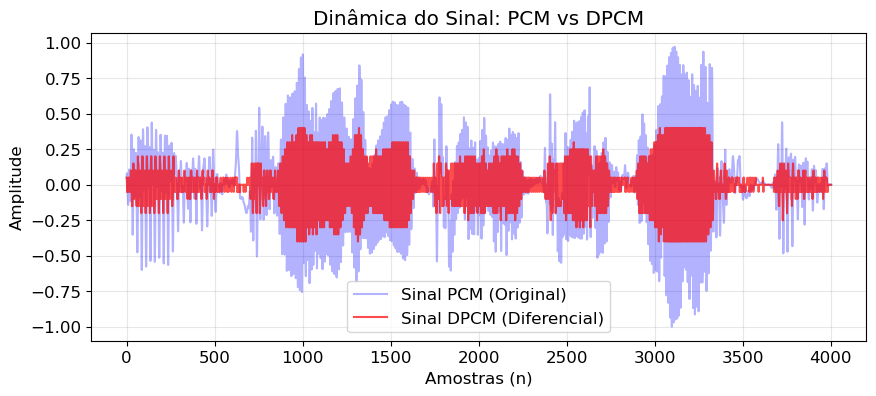

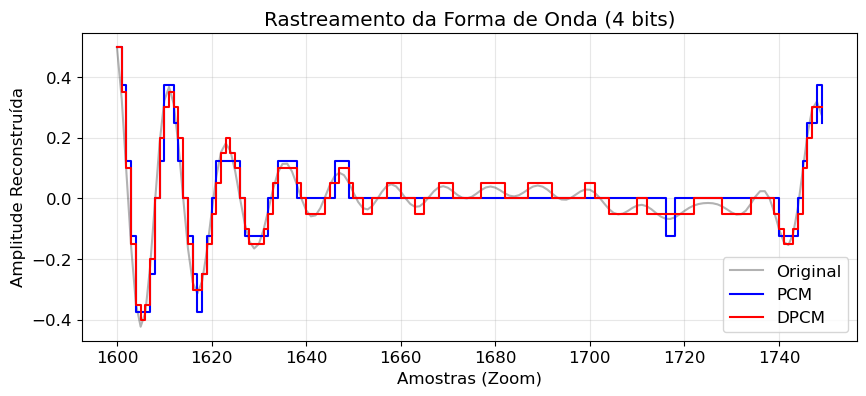

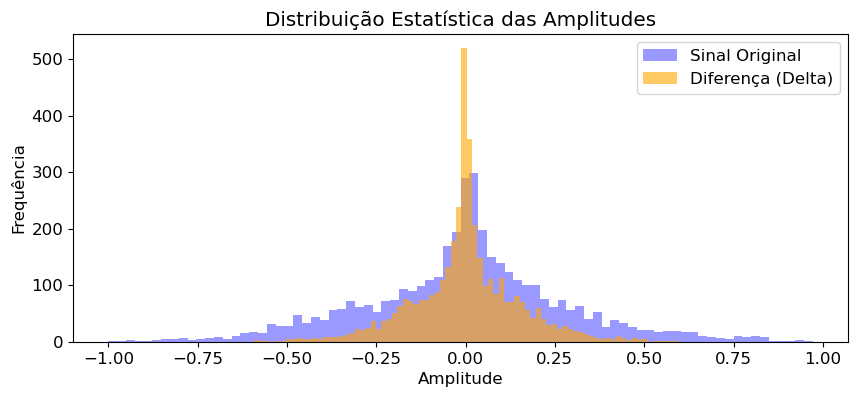

Imagens salvas com sucesso no diretório local!
SNR PCM: 17.98 dB | SNR DPCM: 19.54 dB


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Configuração estética para slides
plt.rcParams.update({'font.size': 12, 'figure.facecolor': 'white'})

# 1. Carregamento de Dados
def load_data_from_url(url):
    response = requests.get(url)
    if response.status_code == 200:
        data = np.loadtxt(BytesIO(response.content), skiprows=1)
        return data
    else:
        raise Exception(f"Erro ao baixar arquivo: Status {response.status_code}")

# 2. Quantizador Uniforme
def uniform_quantizer(signal, bits, v_min=-1, v_max=1):
    levels = 2**bits
    step = (v_max - v_min) / levels
    quantized = np.round((signal - v_min) / step) * step + v_min
    return np.clip(quantized, v_min, v_max)

# 3. Lógica DPCM
def dpcm_encode_decode(signal, bits):
    v_range = 0.4  
    decoded_signal = np.zeros(len(signal))
    transmitted_diffs = np.zeros(len(signal)) 
    prediction = 0
    
    for i in range(len(signal)):
        diff = signal[i] - prediction
        quantized_diff = uniform_quantizer(diff, bits, v_min=-v_range, v_max=v_range)
        transmitted_diffs[i] = quantized_diff
        decoded_signal[i] = prediction + quantized_diff
        prediction = decoded_signal[i]
        
    return decoded_signal, transmitted_diffs

# 4. Médias Móveis
def moving_average(data, window_size=200):
    return np.convolve(np.abs(data), np.ones(window_size)/window_size, mode='same')

# --- Execução ---
github_url = "https://raw.githubusercontent.com/luiz10ml/T27--Digital-Communication/main/Quantizer/VoiceFiltered.dat"

try:
    input_signal = load_data_from_url(github_url)
    input_signal = input_signal / np.max(np.abs(input_signal))

    bits = 4 

    pcm_signal = uniform_quantizer(input_signal, bits)
    error_pcm = input_signal - pcm_signal
    snr_pcm = 10 * np.log10(np.mean(input_signal**2) / (np.mean(error_pcm**2) + 1e-10))

    dpcm_signal, dpcm_transmitted = dpcm_encode_decode(input_signal, bits)
    error_dpcm = input_signal - dpcm_signal
    snr_dpcm = 10 * np.log10(np.mean(input_signal**2) / (np.mean(error_dpcm**2) + 1e-10))

    # --- Plotagem e Salvamento ---
    t = np.arange(len(input_signal))
    
    # Criamos figuras separadas para facilitar o uso nos slides
    fig_names = ["1_excursao", "2_zoom", "3_histograma", "4_erro_medio", "5_residuos"]
    
    # 1. Comparação de Excursão
    plt.figure(figsize=(10, 4))
    plt.plot(t, input_signal, color='blue', alpha=0.3, label='Sinal PCM (Original)')
    plt.plot(t, dpcm_transmitted, color='red', alpha=0.7, label='Sinal DPCM (Diferencial)')
    plt.title('Dinâmica do Sinal: PCM vs DPCM')
    plt.xlabel('Amostras (n)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('grafico_excursao.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 2. Zoom na Reconstrução
    start, end = 1600, 1750
    plt.figure(figsize=(10, 4))
    plt.plot(t[start:end], input_signal[start:end], 'k', label='Original', alpha=0.3)
    plt.step(t[start:end], pcm_signal[start:end], 'blue', label='PCM', where='post')
    plt.step(t[start:end], dpcm_signal[start:end], 'red', label='DPCM', where='post', linewidth=1.5)
    plt.title(f'Rastreamento da Forma de Onda ({bits} bits)')
    plt.xlabel('Amostras (Zoom)')
    plt.ylabel('Amplitude Reconstruída')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('grafico_zoom.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 3. Histograma
    plt.figure(figsize=(10, 4))
    plt.hist(input_signal, bins=80, alpha=0.4, color='blue', label='Sinal Original')
    plt.hist(np.diff(input_signal), bins=80, alpha=0.6, color='orange', label='Diferença (Delta)')
    plt.title('Distribuição Estatística das Amplitudes')
    plt.xlabel('Amplitude')
    plt.ylabel('Frequência')
    plt.legend()
    plt.savefig('grafico_histograma.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Imagens salvas com sucesso no diretório local!")
    print(f"SNR PCM: {snr_pcm:.2f} dB | SNR DPCM: {snr_dpcm:.2f} dB")

except Exception as e:
    print(f"Erro: {e}")